# 00 — Data Visualization: Understanding the Raw Data & Feature Intuition

This notebook visualizes the raw OHLC and headline data so you can see **why** each feature was chosen.

Each section shows a pattern in the data and maps it to the feature that captures it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

# Load data
bars_seen = pd.read_parquet("../data/bars_seen_train.parquet")
bars_unseen = pd.read_parquet("../data/bars_unseen_train.parquet")
headlines_seen = pd.read_parquet("../data/headlines_seen_train.parquet")

# Combine for full session view
bars_all = pd.concat([bars_seen, bars_unseen]).sort_values(["session", "bar_ix"])

# Compute target
halfway_close = bars_seen.groupby("session")["close"].last()
end_close = bars_unseen.groupby("session")["close"].last()
target = end_close / halfway_close - 1
target.name = "target_return"

print(f"Sessions: {bars_seen['session'].nunique()}")
print(f"Bars per session: {bars_seen.groupby('session').size().iloc[0]} seen + {bars_unseen.groupby('session').size().iloc[0]} unseen")
print(f"Target return: mean={target.mean():.4f}, std={target.std():.4f}, {(target > 0).mean():.1%} positive")

Sessions: 1000
Bars per session: 50 seen + 50 unseen
Target return: mean=0.0035, std=0.0204, 57.0% positive


---
## 1. What Does a Session Look Like?

Each session is a synthetic stock with 100 bars. We see bars 0–49 (blue) and must predict
what happens in bars 50–99 (green/red). The vertical dashed line is our **decision point**.

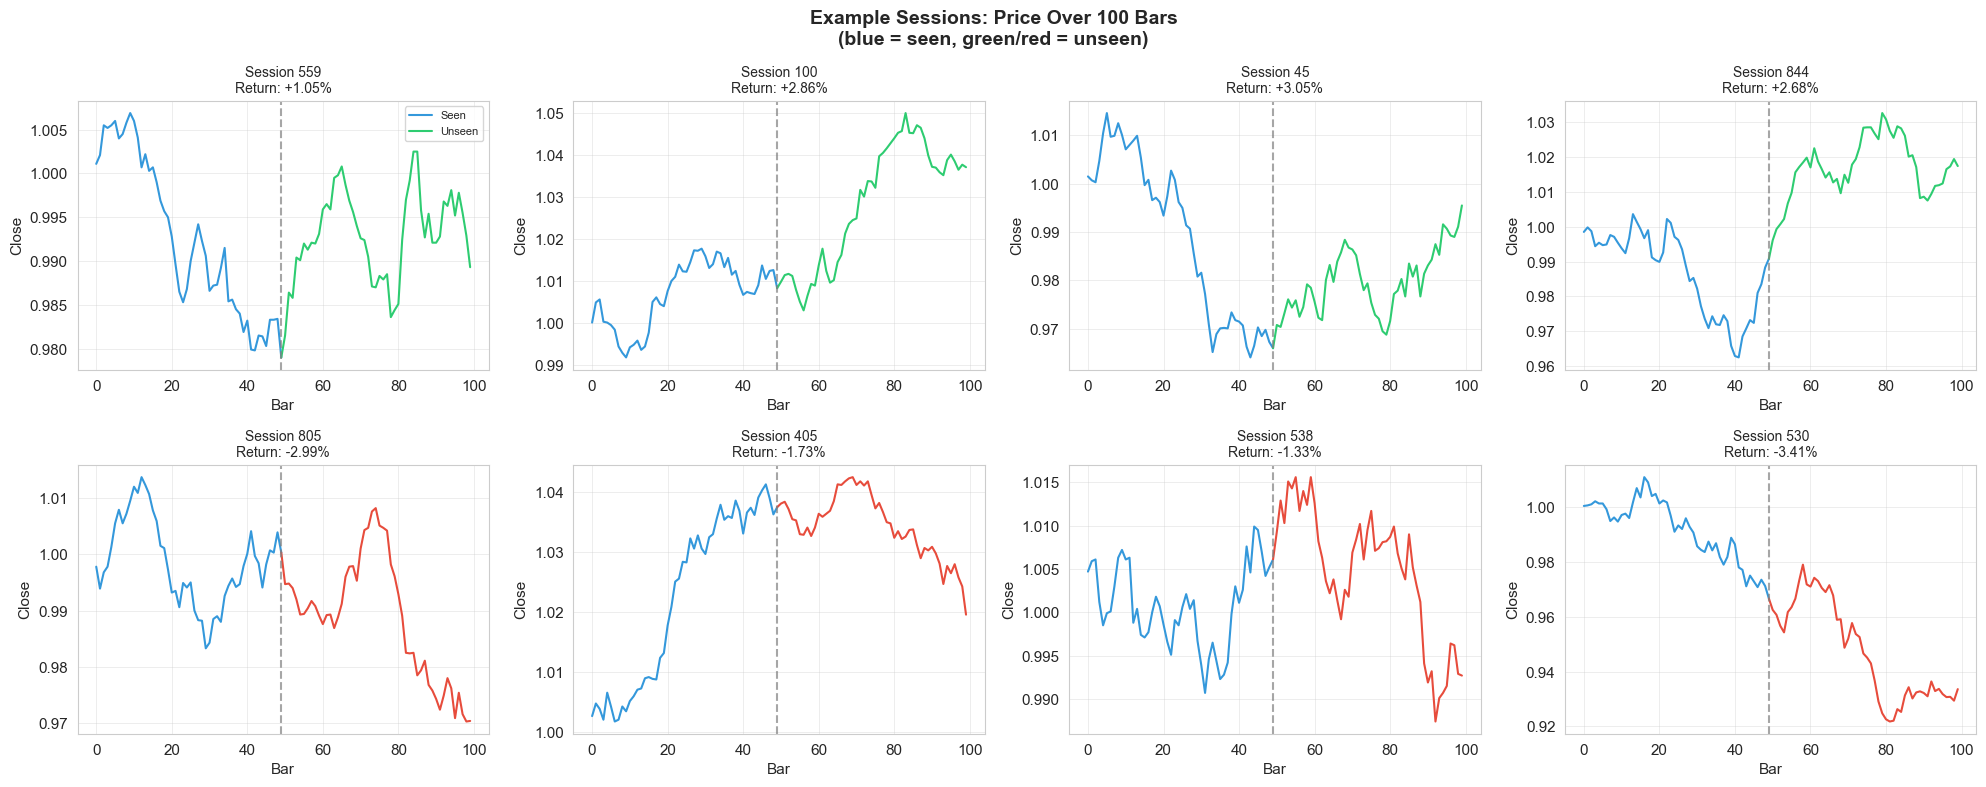

In [2]:
# Pick 8 sessions: 4 with positive second-half return, 4 with negative
np.random.seed(42)
pos_sessions = target[target > 0.01].sample(4).index.tolist()
neg_sessions = target[target < -0.01].sample(4).index.tolist()
example_sessions = pos_sessions + neg_sessions

fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle("Example Sessions: Price Over 100 Bars\n(blue = seen, green/red = unseen)", fontsize=14, fontweight="bold")

for ax, sess in zip(axes.flat, example_sessions):
    sess_bars = bars_all[bars_all["session"] == sess].sort_values("bar_ix")
    seen = sess_bars[sess_bars["bar_ix"] <= 49]
    unseen = sess_bars[sess_bars["bar_ix"] >= 49]  # overlap at 49 for continuity
    ret = target.loc[sess]
    color = "#2ecc71" if ret > 0 else "#e74c3c"

    ax.plot(seen["bar_ix"], seen["close"], color="#3498db", linewidth=1.5, label="Seen")
    ax.plot(unseen["bar_ix"], unseen["close"], color=color, linewidth=1.5, label="Unseen")
    ax.axvline(x=49, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"Session {sess}\nReturn: {ret:+.2%}", fontsize=10)
    ax.set_xlabel("Bar")
    ax.set_ylabel("Close")

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/01_session_examples.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Target Return Distribution

The second-half return (what we're predicting) has a slight positive drift.
57% of sessions go up — this is why "always long" is a strong baseline.

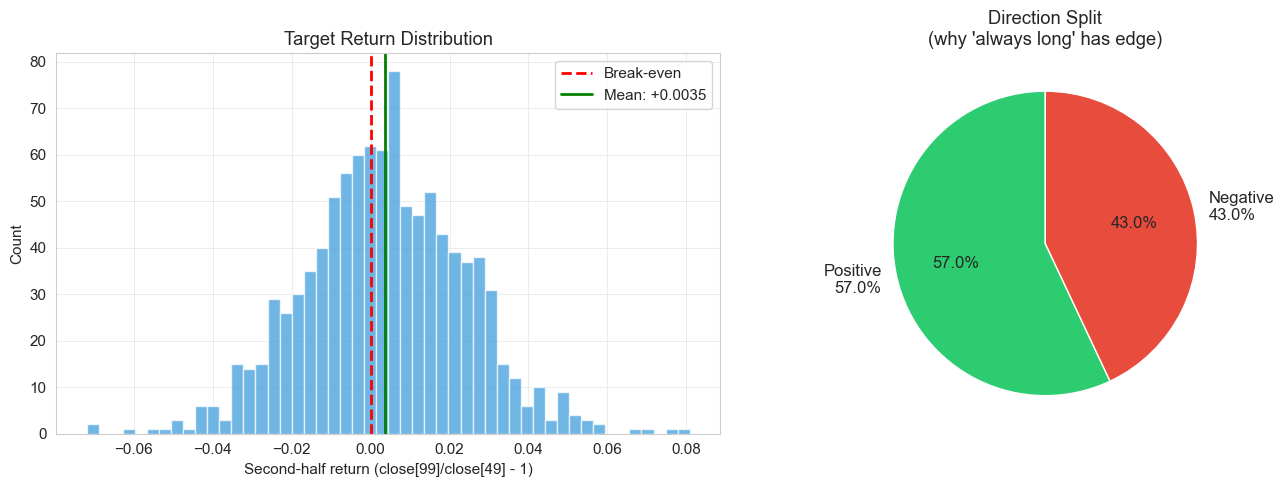

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(target, bins=50, color="#3498db", alpha=0.7, edgecolor="white")
ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Break-even")
ax.axvline(x=target.mean(), color="green", linestyle="-", linewidth=2, label=f"Mean: {target.mean():+.4f}")
ax.set_xlabel("Second-half return (close[99]/close[49] - 1)")
ax.set_ylabel("Count")
ax.set_title("Target Return Distribution")
ax.legend()

# Pie chart: positive vs negative
ax = axes[1]
pos_pct = (target > 0).mean()
neg_pct = 1 - pos_pct
ax.pie([pos_pct, neg_pct], labels=[f"Positive\n{pos_pct:.1%}", f"Negative\n{neg_pct:.1%}"],
       colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%", startangle=90,
       textprops={"fontsize": 12})
ax.set_title("Direction Split\n(why 'always long' has edge)")

plt.tight_layout()
plt.savefig("figures/02_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Feature Intuition: First-Half Return → Mean Reversion

**Feature**: `first_half_return = close[49] / close[0] - 1`  
**Signal**: r = -0.069 (p=0.028)  
**Intuition**: Sessions that went UP in the first half tend to come DOWN in the second half (and vice versa). This is a classic **mean-reversion** signal.

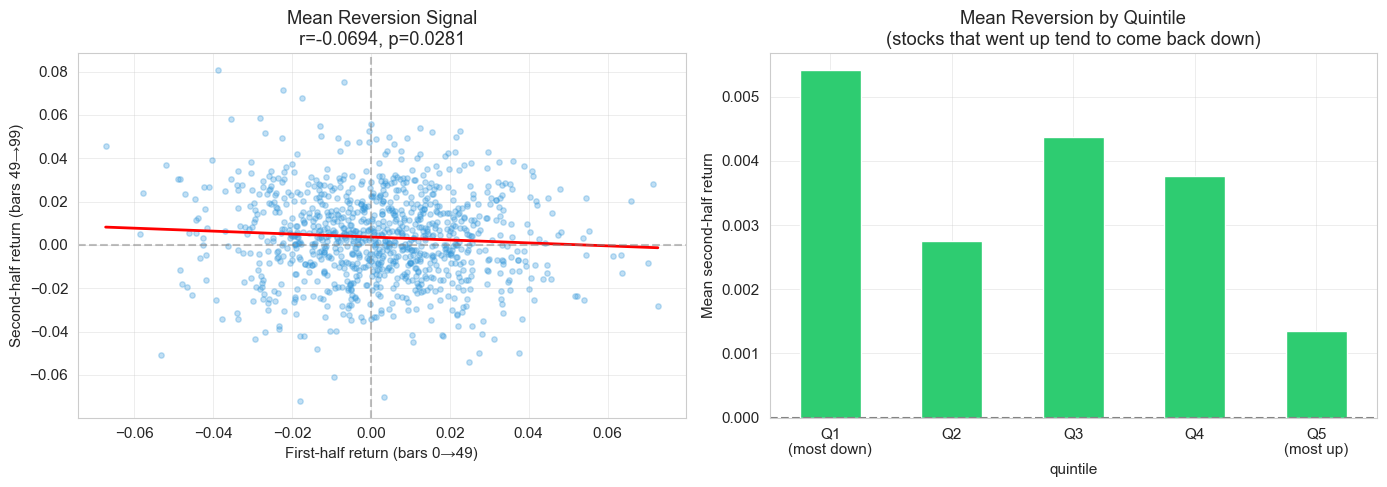

In [5]:
first_close = bars_seen.groupby("session")["close"].first()
last_close = bars_seen.groupby("session")["close"].last()
first_half_return = last_close / first_close - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(first_half_return, target, alpha=0.3, s=15, color="#3498db")
# Regression line
z = np.polyfit(first_half_return, target, 1)
x_line = np.linspace(first_half_return.min(), first_half_return.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2)
r, p = stats.pearsonr(first_half_return, target)
ax.set_xlabel("First-half return (bars 0→49)")
ax.set_ylabel("Second-half return (bars 49→99)")
ax.set_title(f"Mean Reversion Signal\nr={r:.4f}, p={p:.4f}")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

# Quintile bar chart
ax = axes[1]
df = pd.DataFrame({"first_half": first_half_return, "target": target})
df["quintile"] = pd.qcut(df["first_half"], 5, labels=["Q1\n(most down)", "Q2", "Q3", "Q4", "Q5\n(most up)"])
means = df.groupby("quintile", observed=True)["target"].mean()
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in means]
means.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_ylabel("Mean second-half return")
ax.set_title("Mean Reversion by Quintile\n(stocks that went up tend to come back down)")
ax.axhline(y=0, color="gray", linestyle="--")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("figures/03_mean_reversion.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Feature Intuition: Volatility → Higher Future Returns

**Feature**: `volatility = std(log(close/open))` per session  
**Signal**: r = +0.072 (p=0.023)  
**Intuition**: Sessions with higher bar-level volatility in the first half tend to have higher returns in the second half. Volatile sessions = bigger moves = more upside on average.

In [ ]:
bars_seen_c = bars_seen.copy()
bars_seen_c["log_ret"] = np.log(bars_seen_c["close"] / bars_seen_c["open"])
volatility = bars_seen_c.groupby("session")["log_ret"].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(volatility, target, alpha=0.3, s=15, color="#9b59b6")
z = np.polyfit(volatility, target, 1)
x_line = np.linspace(volatility.min(), volatility.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2)
r, p = stats.pearsonr(volatility, target)
ax.set_xlabel("First-half volatility (std of log returns)")
ax.set_ylabel("Second-half return")
ax.set_title(f"Volatility → Higher Returns\nr={r:.4f}, p={p:.4f}")

# Box plot: low vol vs high vol
ax = axes[1]
df = pd.DataFrame({"volatility": volatility, "target": target})
df["vol_regime"] = pd.qcut(df["volatility"], 3, labels=["Low Vol", "Medium Vol", "High Vol"])
df.boxplot(column="target", by="vol_regime", ax=ax,
           boxprops=dict(color="#9b59b6"), medianprops=dict(color="red"))
ax.set_title("Second-Half Return by Volatility Regime")
ax.set_xlabel("First-half volatility regime")
ax.set_ylabel("Second-half return")
plt.suptitle("")  # remove auto title

plt.tight_layout()
plt.savefig("figures/04_volatility_signal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Feature Intuition: Avg High-Low Range → Price Activity

**Feature**: `avg_hl_range = mean((high - low) / open)` per session  
**Signal**: r = +0.078 (p=0.013)  
**Intuition**: Similar to volatility but captures intra-bar price swings. Wider bars = more active trading = higher future returns.

In [ ]:
bars_seen_c["hl_range"] = (bars_seen["high"] - bars_seen["low"]) / bars_seen["open"]
avg_hl_range = bars_seen_c.groupby("session")["hl_range"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(avg_hl_range, target, alpha=0.3, s=15, color="#e67e22")
z = np.polyfit(avg_hl_range, target, 1)
x_line = np.linspace(avg_hl_range.min(), avg_hl_range.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2)
r, p = stats.pearsonr(avg_hl_range, target)
ax.set_xlabel("Avg high-low range / open")
ax.set_ylabel("Second-half return")
ax.set_title(f"Bar Range → Higher Returns\nr={r:.4f}, p={p:.4f}")

# Distribution of avg_hl_range
ax = axes[1]
ax.hist(avg_hl_range, bins=40, color="#e67e22", alpha=0.7, edgecolor="white")
ax.set_xlabel("Avg high-low range / open")
ax.set_ylabel("Count")
ax.set_title("Distribution of Avg H-L Range")

plt.tight_layout()
plt.savefig("figures/05_hl_range_signal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Feature Intuition: Up-Bar Ratio → Directional Consistency

**Feature**: `up_ratio = count(close > open) / 50`  
**Signal**: r = -0.059 (p=0.061)  
**Intuition**: If most bars closed up in the first half, the stock tends to pull back in the second half. Another face of mean-reversion — too many up bars = overextended.

In [ ]:
bars_seen_c["is_up"] = (bars_seen["close"] > bars_seen["open"]).astype(int)
up_ratio = bars_seen_c.groupby("session")["is_up"].mean()

fig, ax = plt.subplots(figsize=(10, 5))

df = pd.DataFrame({"up_ratio": up_ratio, "target": target})
df["up_bucket"] = pd.cut(df["up_ratio"], bins=5)
means = df.groupby("up_bucket", observed=True)["target"].mean()
colors = ["#2ecc71" if v > target.mean() else "#e74c3c" for v in means]
means.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.axhline(y=target.mean(), color="gray", linestyle="--", label=f"Overall mean: {target.mean():.4f}")
r, p = stats.pearsonr(up_ratio, target)
ax.set_xlabel("Fraction of up-bars in first half")
ax.set_ylabel("Mean second-half return")
ax.set_title(f"Up-Bar Ratio: More Up Bars → Lower Future Returns\nr={r:.4f}, p={p:.4f}")
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig("figures/06_up_ratio_signal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Feature Intuition: Close Position in Range

**Feature**: `close_rel_range = (close[49] - session_low) / (session_high - session_low)`  
**Signal**: r = -0.055 (p=0.083)  
**Intuition**: If the price at bar 49 is near the session high, it tends to reverse. If near the low, it tends to bounce. Measures where the "decision point" sits within the first half's range.

In [ ]:
session_high = bars_seen.groupby("session")["high"].max()
session_low = bars_seen.groupby("session")["low"].min()
bar49_close = bars_seen[bars_seen["bar_ix"] == 49].set_index("session")["close"]
close_rel_range = (bar49_close - session_low) / (session_high - session_low)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(close_rel_range, target, alpha=0.3, s=15, color="#1abc9c")
z = np.polyfit(close_rel_range, target, 1)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2)
r, p = stats.pearsonr(close_rel_range, target)
ax.set_xlabel("Close position in range (0 = at low, 1 = at high)")
ax.set_ylabel("Second-half return")
ax.set_title(f"Close Near Session High → Lower Future Returns\nr={r:.4f}, p={p:.4f}")

# Quintile bar chart
ax = axes[1]
df = pd.DataFrame({"close_rel": close_rel_range, "target": target})
df["quintile"] = pd.qcut(df["close_rel"], 5, labels=["Near Low", "Q2", "Mid", "Q4", "Near High"])
means = df.groupby("quintile", observed=True)["target"].mean()
colors = ["#2ecc71" if v > target.mean() else "#e74c3c" for v in means]
means.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.axhline(y=target.mean(), color="gray", linestyle="--")
ax.set_ylabel("Mean second-half return")
ax.set_title("Return by Close Position in Range")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("figures/07_close_rel_range.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. The Headline Problem: Why Sentiment Doesn't Work

Headlines from bars 0–49 have **zero** correlation with second-half returns.  
Headlines from bars 50–99 have **strong** correlation — but we can't use them at test time.

In [ ]:
headlines_unseen = pd.read_parquet("../data/headlines_unseen_train.parquet")

pos_words = ["secures", "strong", "raises", "breakthrough", "gains", "surge", "expands"]
neg_words = ["misses", "decline", "withdraws", "warns", "disruptions", "downgrades", "recall"]

def keyword_sentiment(headline):
    h = headline.lower()
    return sum(1 for w in pos_words if w in h) - sum(1 for w in neg_words if w in h)

# Seen sentiment
headlines_seen_c = headlines_seen.copy()
headlines_seen_c["sent"] = headlines_seen_c["headline"].apply(keyword_sentiment)
seen_sent = headlines_seen_c.groupby("session")["sent"].sum()

# Unseen sentiment
headlines_unseen_c = headlines_unseen.copy()
headlines_unseen_c["sent"] = headlines_unseen_c["headline"].apply(keyword_sentiment)
unseen_sent = headlines_unseen_c.groupby("session")["sent"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seen sentiment (DEAD)
ax = axes[0]
common = seen_sent.index.intersection(target.index)
ax.scatter(seen_sent.loc[common], target.loc[common], alpha=0.3, s=15, color="#95a5a6")
r, p = stats.pearsonr(seen_sent.loc[common], target.loc[common])
ax.set_xlabel("Seen headline sentiment (bars 0-49)")
ax.set_ylabel("Second-half return")
ax.set_title(f"SEEN Headlines: NO Signal\nr={r:.4f}, p={p:.4f}\n(This is all we have at test time)", color="red")

# Unseen sentiment (STRONG but unusable)
ax = axes[1]
common2 = unseen_sent.index.intersection(target.index)
ax.scatter(unseen_sent.loc[common2], target.loc[common2], alpha=0.3, s=15, color="#2ecc71")
z = np.polyfit(unseen_sent.loc[common2], target.loc[common2], 1)
x_line = np.linspace(unseen_sent.min(), unseen_sent.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2)
r, p = stats.pearsonr(unseen_sent.loc[common2], target.loc[common2])
ax.set_xlabel("Unseen headline sentiment (bars 50-99)")
ax.set_ylabel("Second-half return")
ax.set_title(f"UNSEEN Headlines: Strong Signal\nr={r:.4f}, p={p:.4f}\n(But unavailable at test time!)", color="green")

plt.tight_layout()
plt.savefig("figures/08_headline_seen_vs_unseen.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. The ONE Useful Headline Feature: Revenue Event Count

**Feature**: `revenue_event_count` — number of headlines mentioning revenue/earnings  
**Signal**: r = -0.082 (p=0.010) — our **strongest single feature**  
**Intuition**: Sessions with more revenue/earnings headlines in the first half tend to have lower second-half returns. Revenue news may signal uncertainty or negative surprises.

In [ ]:
revenue_kw = ["revenue", "quarterly", "earnings", "estimates"]
headlines_seen_c["is_revenue"] = headlines_seen_c["headline"].str.lower().apply(
    lambda t: int(any(kw in t for kw in revenue_kw))
)
revenue_count = headlines_seen_c.groupby("session")["is_revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart by revenue count
ax = axes[0]
df = pd.DataFrame({"rev_count": revenue_count, "target": target})
means = df.groupby("rev_count")["target"].agg(["mean", "count"])
means = means[means["count"] >= 10]  # only show buckets with enough data
colors = ["#2ecc71" if v > target.mean() else "#e74c3c" for v in means["mean"]]
ax.bar(means.index, means["mean"], color=colors, edgecolor="white")
ax.axhline(y=target.mean(), color="gray", linestyle="--", label=f"Overall mean: {target.mean():.4f}")
ax.set_xlabel("Number of revenue/earnings headlines in session")
ax.set_ylabel("Mean second-half return")
ax.set_title("More Revenue Headlines → Lower Returns")
ax.legend()

# Distribution of revenue count
ax = axes[1]
revenue_count.value_counts().sort_index().plot(kind="bar", ax=ax, color="#e67e22", edgecolor="white")
ax.set_xlabel("Revenue headline count per session")
ax.set_ylabel("Number of sessions")
ax.set_title("Distribution of Revenue Headlines")

plt.tight_layout()
plt.savefig("figures/09_revenue_signal.png", dpi=150, bbox_inches="tight")
plt.show()

r, p = stats.pearsonr(revenue_count.reindex(target.index, fill_value=0), target)
print(f"Revenue event count vs target: r={r:.4f}, p={p:.4f}")

---
## 10. What a Typical Session's Headlines Look Like

Each session mentions ~4 fictional companies. Not all are relevant. Headlines have explicit sentiment words.

In [ ]:
import re

# Show 3 example sessions with their headlines
example_sessions = [0, 42, 369]
for sess in example_sessions:
    hl = headlines_seen[headlines_seen["session"] == sess].sort_values("bar_ix")
    ret = target.loc[sess]

    # Extract companies
    companies = []
    for h in hl["headline"]:
        m = re.match(r'^([A-Z][a-z]+ [A-Z][a-z]+)', h)
        if m:
            companies.append(m.group(1))
    company_counts = pd.Series(companies).value_counts()

    print(f"\n{'='*80}")
    print(f"Session {sess}  |  Target return: {ret:+.4f}  |  {len(hl)} headlines")
    print(f"Companies: {dict(company_counts)}")
    print(f"{'='*80}")
    for _, row in hl.iterrows():
        sent = keyword_sentiment(row['headline'])
        marker = " [+]" if sent > 0 else " [-]" if sent < 0 else ""
        print(f"  Bar {row['bar_ix']:2d}: {row['headline']}{marker}")

---
## 11. All Features Signal Strength Summary

Visual version of the BATTLE_PLAN.md signal landscape table.

In [ ]:
# Collect all correlations
bar30_close = bars_seen[bars_seen["bar_ix"] == 30].set_index("session")["close"]
ret_from_30 = bar49_close / bar30_close - 1

features_dict = {
    "revenue_event_count": revenue_count.reindex(target.index, fill_value=0),
    "ret_from_30": ret_from_30,
    "avg_hl_range": avg_hl_range,
    "volatility": volatility,
    "first_half_return": first_half_return,
    "up_ratio": up_ratio,
    "close_rel_range": close_rel_range,
    "keyword_sentiment": seen_sent.reindex(target.index, fill_value=0),
    "headline_count": headlines_seen.groupby("session").size().reindex(target.index, fill_value=0),
}

corrs = []
for name, feat in features_dict.items():
    common = feat.index.intersection(target.index)
    r, p = stats.pearsonr(feat.loc[common], target.loc[common])
    corrs.append({"feature": name, "r": r, "abs_r": abs(r), "p": p})

corr_df = pd.DataFrame(corrs).sort_values("abs_r", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#3498db" if row["p"] < 0.05 else "#bdc3c7" for _, row in corr_df.iterrows()]
ax.barh(corr_df["feature"], corr_df["r"], color=colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Pearson correlation with second-half return")
ax.set_title("Feature Signal Strength\n(blue = p < 0.05, gray = not significant)")

# Annotate p-values
for i, (_, row) in enumerate(corr_df.iterrows()):
    offset = 0.003 if row["r"] >= 0 else -0.003
    ha = "left" if row["r"] >= 0 else "right"
    ax.text(row["r"] + offset, i, f"p={row['p']:.3f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig("figures/10_signal_summary.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. OHLC Candlestick View: What Bars Actually Look Like

Show the raw OHLC structure for a few sessions to build intuition about the data granularity.

In [ ]:
def plot_candlestick(ax, bars_df, title=""):
    """Simple candlestick-style plot."""
    for _, row in bars_df.iterrows():
        color = "#2ecc71" if row["close"] >= row["open"] else "#e74c3c"
        # High-low wick
        ax.plot([row["bar_ix"], row["bar_ix"]], [row["low"], row["high"]],
                color=color, linewidth=0.5)
        # Open-close body
        body_bottom = min(row["open"], row["close"])
        body_height = abs(row["close"] - row["open"])
        ax.bar(row["bar_ix"], body_height, bottom=body_bottom, width=0.6,
               color=color, edgecolor=color)
    ax.set_title(title)
    ax.set_xlabel("Bar")
    ax.set_ylabel("Price")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, sess in zip(axes, [0, 42, 100]):
    sess_bars = bars_seen[bars_seen["session"] == sess].sort_values("bar_ix")
    ret = target.loc[sess]
    plot_candlestick(ax, sess_bars, f"Session {sess} (target: {ret:+.2%})")
    ax.axvline(x=49, color="blue", linestyle="--", alpha=0.5)

plt.suptitle("OHLC Candlestick View of Seen Bars (0-49)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/11_candlesticks.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Key Takeaways

| # | Insight | Feature | r | Action |
|---|---------|---------|---|--------|
| 1 | 57% of returns are positive | — | — | Always-long baseline is strong (Sharpe 2.77) |
| 2 | Mean-reversion: up first half → down second half | `first_half_return` | -0.069 | Negative weight in model |
| 3 | Recent trend slightly stronger signal | `ret_from_30` | -0.081 | Use instead of/alongside full return |
| 4 | Volatile sessions have higher future returns | `volatility` | +0.072 | Positive weight |
| 5 | Wide bars = active session = more upside | `avg_hl_range` | +0.078 | Positive weight |
| 6 | Too many up-bars → overextended | `up_ratio` | -0.059 | Marginal but keep |
| 7 | Close near session high → reversal likely | `close_rel_range` | -0.055 | Marginal |
| 8 | Revenue headlines = bad news | `revenue_event_count` | -0.082 | **Strongest feature** |
| 9 | Keyword sentiment from seen bars is DEAD | — | 0.018 | Don't waste time on NLP |
| 10 | Unseen headline sentiment is strong but unusable | — | 0.244 | Can't use at test time |